# Project code

## Preprocessing

Using the all of the data (WGS and WES) multiple different models were used in the preliminary testing of models. Data relating to PCAWG was chosen as model accuracy was low due to the fact that using all of the data added too much noise. The final used data is a combination of 96 catalogs and related activities. Labels with less than 30 samples were excluded. 

In [1]:
# Imports 
import os, re, json, math, warnings, copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score,
                             precision_recall_fscore_support)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
import warnings
from sklearn.exceptions import ConvergenceWarning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight


In [2]:
## PCAWG data is performed by the same pipeline
PCAWG_wgs_mut = pd.read_csv ("./project_data/catalogs/WGS/WGS_PCAWG.96.csv")
PCAWG_wgs_mut.head(2)


## Activities:
PCAWG_wgs_act = pd.read_csv ("./project_data/activities/WGS/WGS_PCAWG.activities.csv")
PCAWG_wgs_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,Biliary-AdenoCA,SP117655,0.968,1496,1296,0,0,1825,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Biliary-AdenoCA,SP117556,0.963,985,0,0,0,922,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
def process_profile_data(mut_dfs):
    """
    1. Transposes mutation catalogs so samples are rows.
    2. Normalizes counts to sum to 1 (Frequency).
    3. Extracts Cancer Type labels.
    """
    # Concatenate all mutation dataframes horizontally (aligning on Mutation type/Trinucleotide)
    # We assume all dfs have the same 96 rows sorted identically.
    # First, let's create a combined dataframe by dropping the info columns on subsequent dfs
    
    base_df = mut_dfs[0].copy()
    
    # Create the 96-channel index (e.g., C>A_ACA)
    channel_index = base_df['Mutation type'] + "_" + base_df['Trinucleotide']
    
    combined_df = pd.DataFrame(index=channel_index)
    
    for df in mut_dfs:
        # Drop metadata columns to get just sample counts
        temp = df.drop(['Mutation type', 'Trinucleotide'], axis=1)
        # Set index for alignment
        temp.index = channel_index
        combined_df = pd.concat([combined_df, temp], axis=1)
        
    # Transpose: Rows = Samples, Columns = 96 Mutation Channels
    X = combined_df.T
    
    # Extract Labels (Cancer Type) from the index (Sample Name: "CancerType::SampleID")
    # We split by "::" and take the first part
    y = X.index.map(lambda x: x.split("::")[0])
    
    # NORMALIZE: Sum of row = 1 (to handle WGS vs WES scale differences)
    X_norm = X.div(X.sum(axis=1), axis=0)
    
    return X_norm, y

def process_activity_data(act_dfs):
    """
    1. Standardizes index to match Profile data (CancerType::SampleID).
    2. Concatenates all activity dataframes.
    """
    combined_act = pd.DataFrame()
    
    for df in act_dfs:
        temp = df.copy()
        # Create Index matching the Profile format: "CancerType::SampleName"
        # Note: Adjust column names if they differ slightly across files
        temp['index_id'] = temp['Cancer Types'] + "::" + temp['Sample Names']
        temp = temp.set_index('index_id')
        
        # Drop metadata
        cols_to_drop = ['Cancer Types', 'Sample Names', 'Accuracy']
        temp = temp.drop([c for c in cols_to_drop if c in temp.columns], axis=1)
        
        combined_act = pd.concat([combined_act, temp], axis=0)
    
    # Fill NaNs with 0 (in case some files have different sets of signatures)
    combined_act = combined_act.fillna(0)
    
    # Normalize activities to sum to 1 (Optional but good for comparison)
    combined_act = combined_act.div(combined_act.sum(axis=1), axis=0)
    
    return combined_act

# --- Execution ---

# 1. Prepare Lists of Dataframes (Assuming these are already loaded in your notebook)
#list_muts = [PCAWG_wgs_mut, nonPCAWG_wgs_mut]
#list_acts = [PCAWG_wgs_act, nonPCAWG_wgs_act]
list_muts = [PCAWG_wgs_mut]
list_acts = [PCAWG_wgs_act]

'''
During our data exploration, we observed that combining PCAWG WGS data with Other WGS data reduced overall model accuracy by ~10%. 
We hypothesize that this drop is due to batch effects—PCAWG data is uniformly harmonized through a single pipeline, 
whereas external datasets introduce technical noise and variance in mutation calling. 
To ensure our models learn true biological etiology rather than laboratory batch effects, we restricted our final training to the PCAWG cohort.
'''

# 2. Process Data
print("Processing Profiles...")
X_profiles, y_labels = process_profile_data(list_muts)

print("Processing Activities...")
X_activities = process_activity_data(list_acts)

# 3. Create Combined Dataset
# Use intersection of indices to ensure we only keep samples present in both
common_indices = X_profiles.index.intersection(X_activities.index)

X_prof_common = X_profiles.loc[common_indices]
X_act_common = X_activities.loc[common_indices]
y_common = y_labels[X_profiles.index.isin(common_indices)]

# Concatenate for the "Combined" feature set
X_combined = pd.concat([X_prof_common, X_act_common], axis=1)

print(f"Total Samples Processed: {len(y_common)}")
print(f"Profile Features: {X_prof_common.shape[1]}")
print(f"Activity Features: {X_act_common.shape[1]}")

Processing Profiles...
Processing Activities...
Total Samples Processed: 2780
Profile Features: 96
Activity Features: 65


## Models

Brief explanation of models used and why they were picked. 

### Logistic regression

In [4]:
# Prepare mutation features
# Drop first two columns (Mutation type and Trinucleotide) and transpose
mut_X = PCAWG_wgs_mut.drop(['Mutation type', 'Trinucleotide'], axis=1).T
# Name the columns using mutation type + trinucleotide
mut_X.columns = PCAWG_wgs_mut['Mutation type'] + "_" + PCAWG_wgs_mut['Trinucleotide']
# Index = sample names
mut_X.index = [col.split("::")[1] for col in mut_X.index]  # extracts SP IDs

# Prepare signature activities as features
act_X = PCAWG_wgs_act.drop(['Cancer Types', 'Sample Names', 'Accuracy'], axis=1)
act_X.index = PCAWG_wgs_act['Sample Names']

# Labels
y = PCAWG_wgs_act['Cancer Types']
y.index = PCAWG_wgs_act['Sample Names']

# Combine mutation counts + activities
combined_X = pd.concat([mut_X, act_X], axis=1)

# Check alignment
print(mut_X.shape, act_X.shape, combined_X.shape, y.shape)


(2780, 96) (2780, 65) (2780, 161) (2780,)


In [5]:
# Using combined features
X = combined_X  # can also be mut_X or act_X
y_labels = y

# Split data: 80% train, 20% test, stratified by cancer type
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Check shapes
print("Train X shape:", X_train.shape)
print("Test X shape:", X_test.shape)
print("Train y shape:", y_train.shape)
print("Test y shape:", y_test.shape)


Train X shape: (2224, 161)
Test X shape: (556, 161)
Train y shape: (2224,)
Test y shape: (556,)


In [6]:
# Count samples per cancer type
sample_counts = y_train.value_counts()

min_samples = 10
keep_classes = sample_counts[sample_counts >= min_samples].index
X_train_filtered = X_train[y_train.isin(keep_classes)]
y_train_filtered = y_train[y_train.isin(keep_classes)]
X_test_filtered = X_test[y_test.isin(keep_classes)]
y_test_filtered = y_test[y_test.isin(keep_classes)]

In [7]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_filtered)
y_test_enc = le.transform(y_test_filtered)

# Define Logistic Regression (no scaling)
logreg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    C=0.01,
    random_state=42
)

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train on full training set & evaluate on test set
print("\nTraining Logistic Regression...")

logreg.fit(X_train_filtered, y_train_enc)
y_pred_test = logreg.predict(X_test_filtered)

acc_test = accuracy_score(y_test_enc, y_pred_test)
macro_f1_test = f1_score(y_test_enc, y_pred_test, average='macro')
weighted_f1_test = f1_score(y_test_enc, y_pred_test, average='weighted')

print(f"Test set -> Accuracy: {acc_test:.3f}, Macro F1: {macro_f1_test:.3f}, Weighted F1: {weighted_f1_test:.3f}")

# Manual cross-validation on training set
acc_scores, macro_f1_scores, weighted_f1_scores = [], [], []

for train_idx, val_idx in cv.split(X_train_filtered, y_train_enc):
    X_tr, X_val = X_train_filtered.iloc[train_idx], X_train_filtered.iloc[val_idx]
    y_tr, y_val = y_train_enc[train_idx], y_train_enc[val_idx]

    logreg.fit(X_tr, y_tr)
    y_pred = logreg.predict(X_val)

    acc_scores.append(accuracy_score(y_val, y_pred))
    macro_f1_scores.append(f1_score(y_val, y_pred, average='macro'))
    weighted_f1_scores.append(f1_score(y_val, y_pred, average='weighted'))

print("\nCV Metrics (train set, 5-fold):")
print(f"  Accuracy:    {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}")
print(f"  Macro F1:    {np.mean(macro_f1_scores):.3f} ± {np.std(macro_f1_scores):.3f}")
print(f"  Weighted F1: {np.mean(weighted_f1_scores):.3f} ± {np.std(weighted_f1_scores):.3f}")


Training Logistic Regression...
Test set -> Accuracy: 0.776, Macro F1: 0.671, Weighted F1: 0.777

CV Metrics (train set, 5-fold):
  Accuracy:    0.768 ± 0.024
  Macro F1:    0.663 ± 0.046
  Weighted F1: 0.768 ± 0.025


### Random forest

### MLP

In [4]:
# MLP code

### Support Vector Machine (SVM)

In [ ]:
# SVM code

### Neural network

Remaining: 25 cancer types, 2627 samples

Device is set to: cpu

  5-Fold Cross-Validation on Dev Set
  Fold 1: Val Accuracy = 0.8277
  Fold 2: Val Accuracy = 0.8054
  Fold 3: Val Accuracy = 0.8453
  Fold 4: Val Accuracy = 0.7960
  Fold 5: Val Accuracy = 0.7937

  CV Mean ± Std: 0.8136 ± 0.0199

  Ensemble Test Accuracy (5 folds): 0.8557 (85.57%)



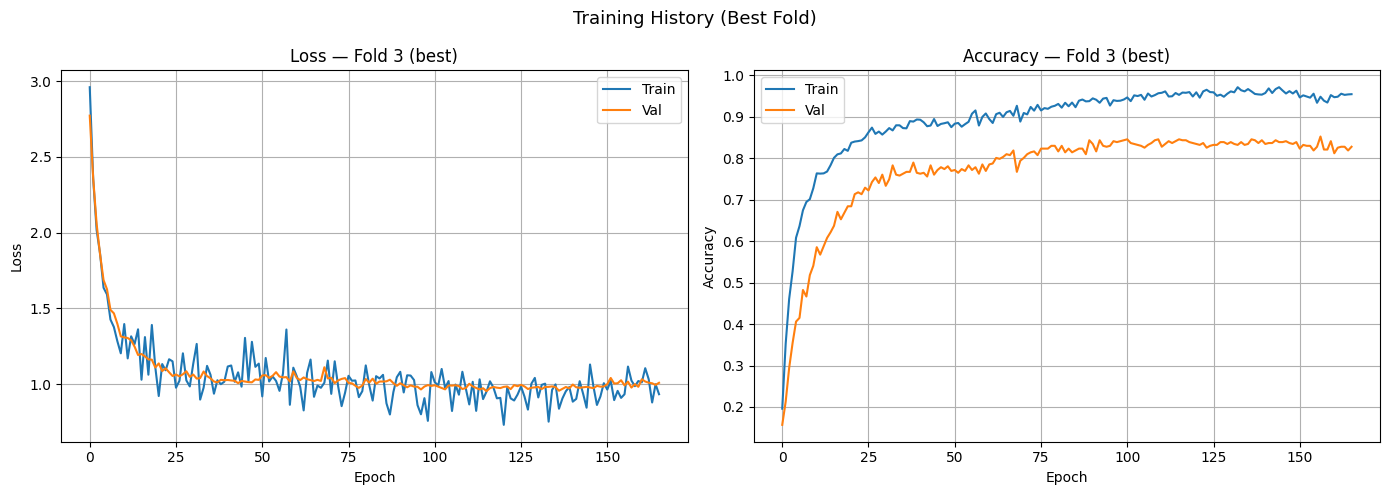

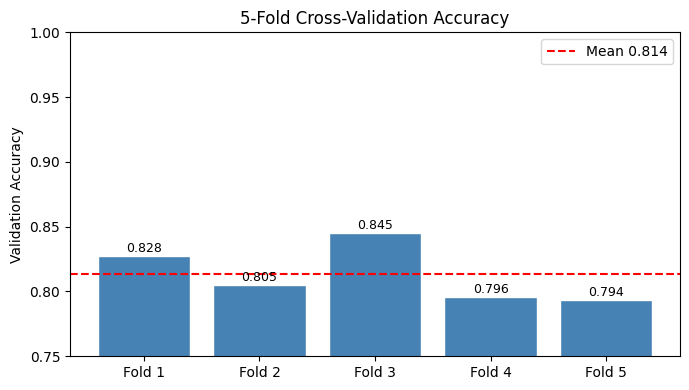

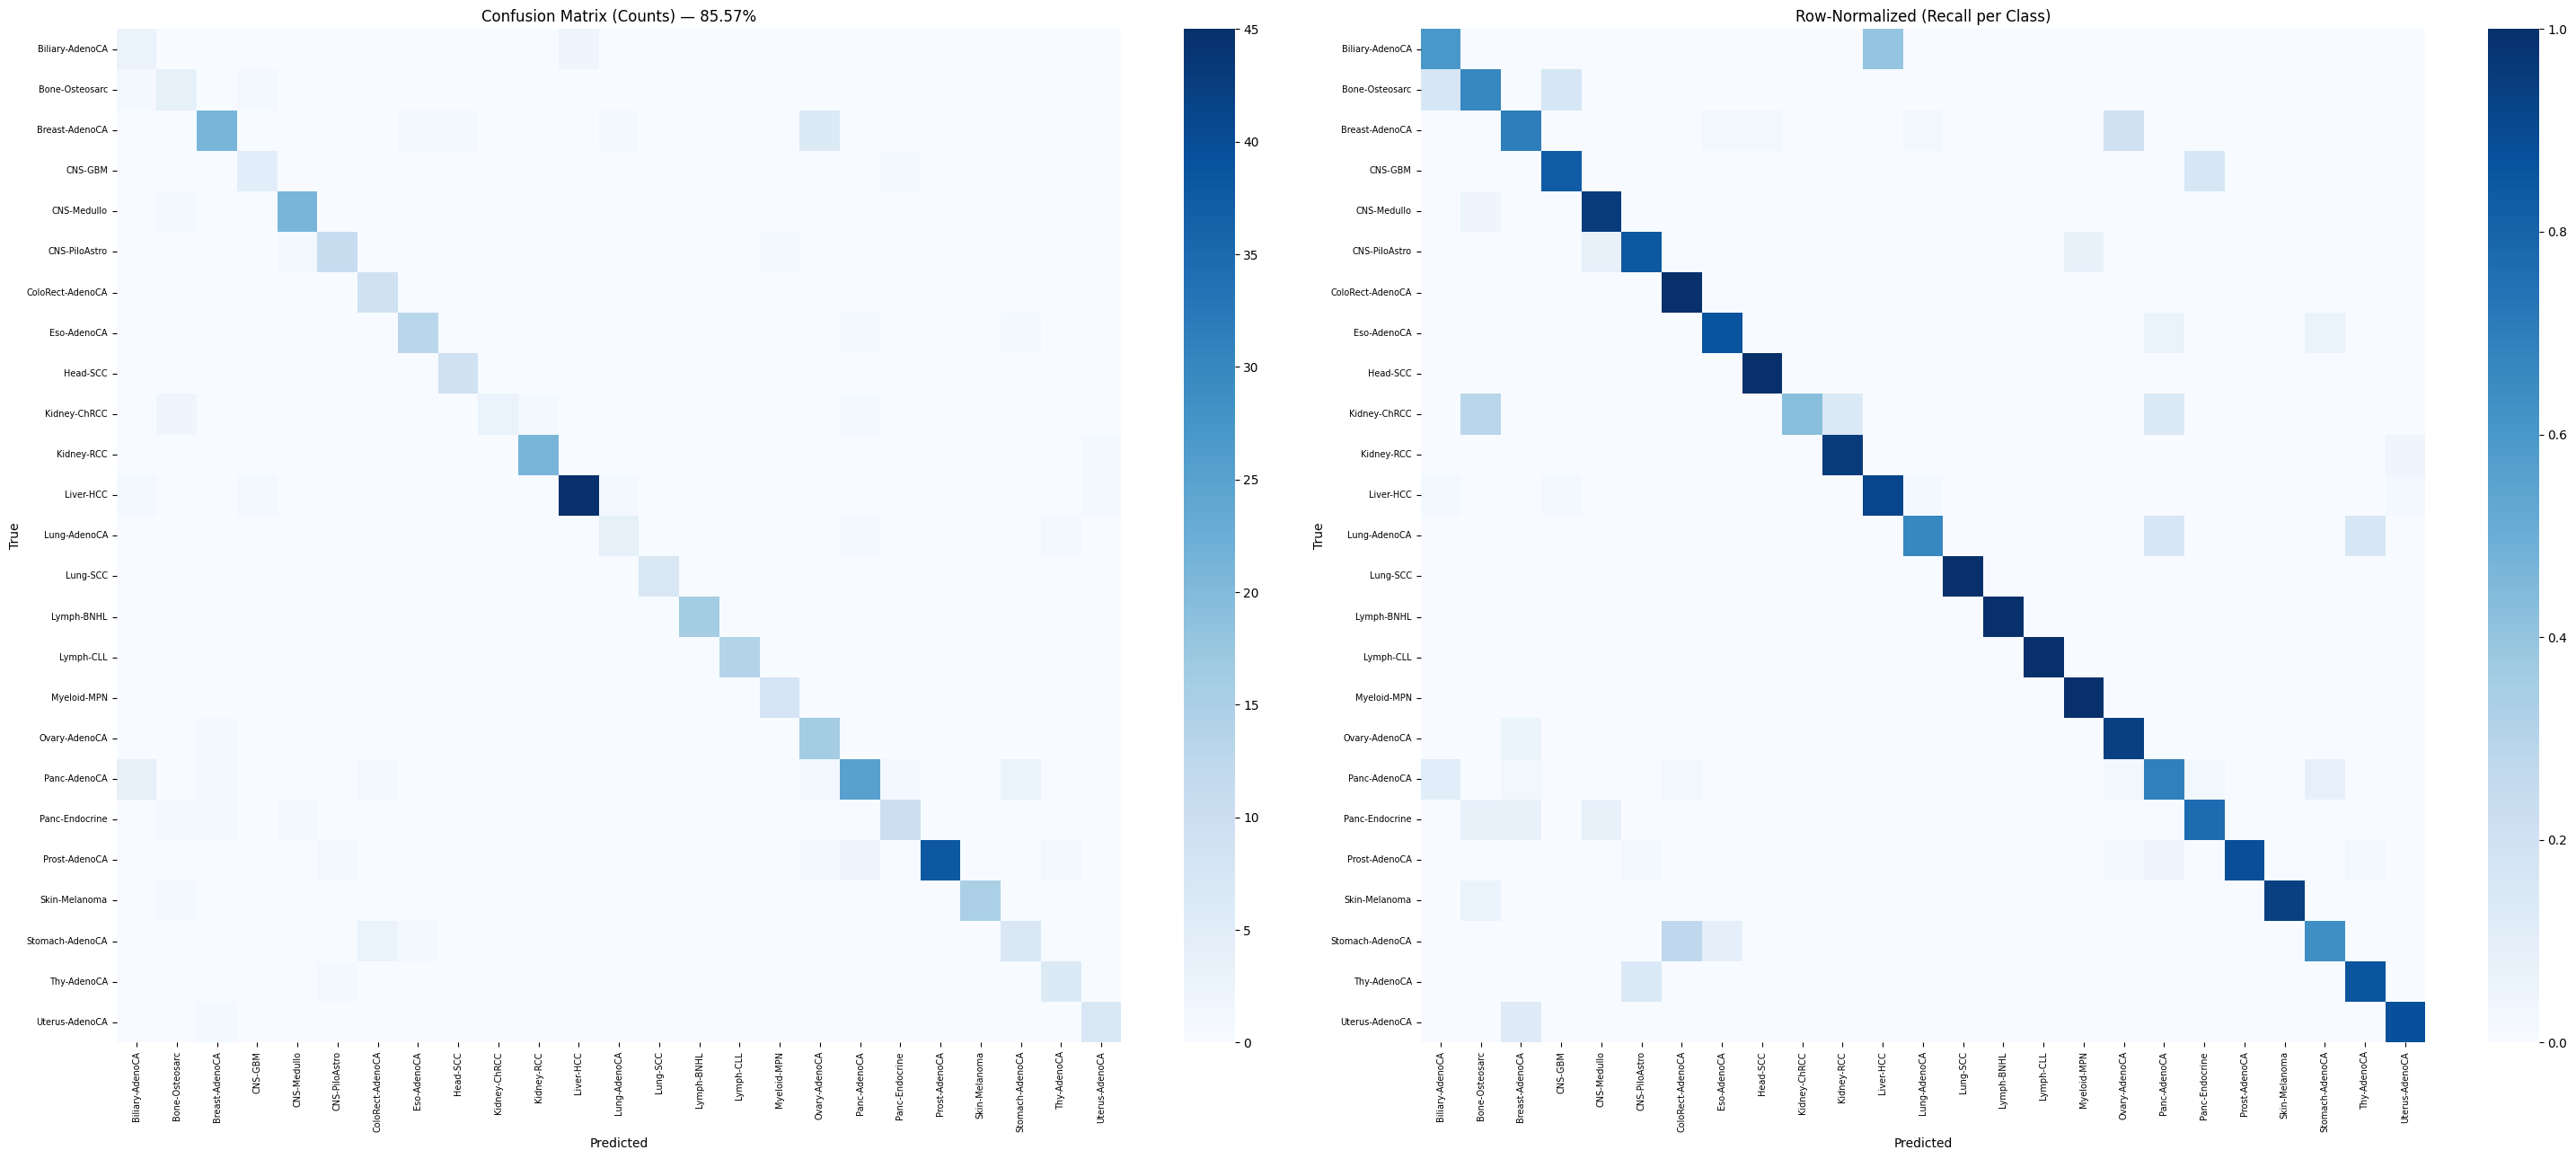

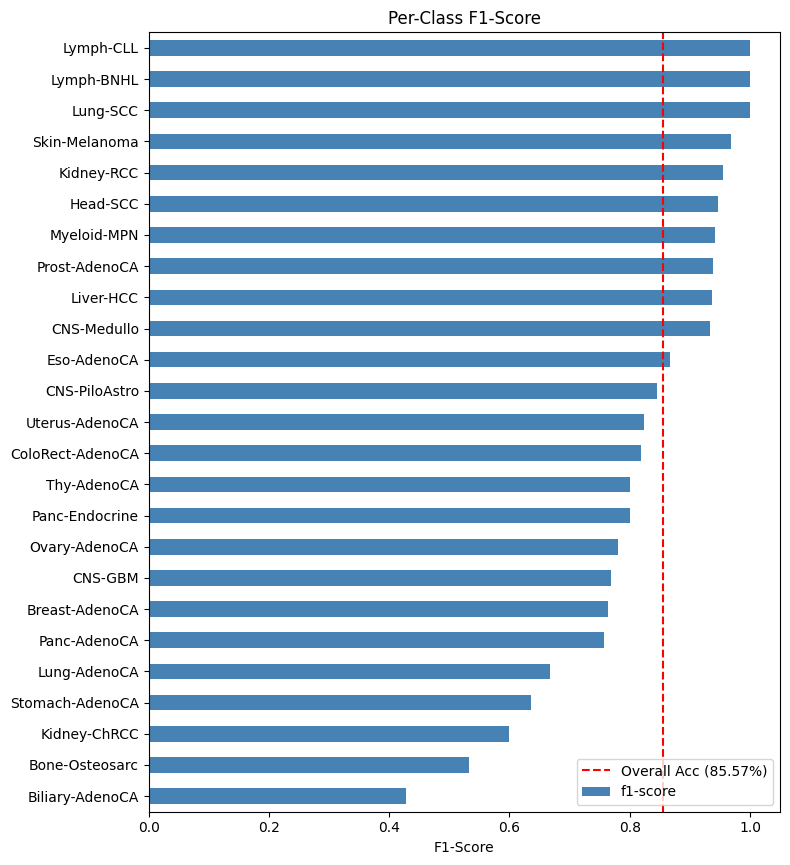


── 5 hardest cancer types ──
                 precision    recall  f1-score  support
Biliary-AdenoCA   0.333333  0.600000  0.428571        5
Bone-Osteosarc    0.444444  0.666667  0.533333        6
Kidney-ChRCC      1.000000  0.428571  0.600000        7
Stomach-AdenoCA   0.636364  0.636364  0.636364       11
Lung-AdenoCA      0.666667  0.666667  0.666667        6

── 5 easiest cancer types ──
               precision    recall  f1-score  support
Kidney-RCC      0.954545  0.954545  0.954545       22
Skin-Melanoma   1.000000  0.937500  0.967742       16
Lung-SCC        1.000000  1.000000  1.000000        7
Lymph-BNHL      1.000000  1.000000  1.000000       16
Lymph-CLL       1.000000  1.000000  1.000000       14


In [8]:
def select_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

# ==========================================
# 0. FILTER RARE CANCER TYPES
# ==========================================
MIN_SAMPLES = 30  # Minimum samples per cancer type to keep

label_counts = pd.Series(y_common).value_counts()
valid_labels  = label_counts[label_counts >= MIN_SAMPLES].index
mask          = pd.Series(y_common).isin(valid_labels).values
X_filtered    = X_combined[mask]
y_filtered    = pd.Series(y_common)[mask].reset_index(drop=True)

print(f"Remaining: {len(valid_labels)} cancer types, {len(y_filtered)} samples\n")
print(f"Device is set to: {select_device()}\n")

# ==========================================
# 1. FEATURE SCALING  (critical for NNs!)
# ==========================================
# Profiles are already normalized to sum=1, but activities vary widely.
# StandardScaler brings all 161 features to zero-mean / unit-variance.
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_filtered),
    index=X_filtered.index,
    columns=X_filtered.columns
)

# ==========================================
# 2. LABEL ENCODING
# ==========================================
label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(y_filtered)
num_classes   = len(label_encoder.classes_)
input_dim     = X_scaled.shape[1]

# ==========================================
# 3. HOLD-OUT TEST SET  (stratified 15%)
# ==========================================
X_dev, X_test, y_dev, y_test = train_test_split(
    X_scaled.values, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded
)

# ==========================================
# 4. MIXUP DATA AUGMENTATION
# ==========================================
def mixup_batch(X, y, alpha=0.3):
    """Returns a mixed batch — interpolates between two random samples."""
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(X.size(0))
    X_mix = lam * X + (1 - lam) * X[idx]
    y_a, y_b = y, y[idx]
    return X_mix, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ==========================================
# 5. ARCHITECTURE  (lighter + more dropout)
# ==========================================
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.net(x))

class CancerNet(nn.Module):
    def __init__(self, input_size, num_classes, hidden=256, dropout=0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(input_size, hidden), nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout)
        )
        self.blocks = nn.Sequential(
            ResBlock(hidden, dropout=0.3),
            ResBlock(hidden, dropout=0.3),
            ResBlock(hidden, dropout=0.3),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))

# ==========================================
# 6. TRAIN ONE FOLD  (reusable function)
# ==========================================
def train_fold(X_tr, y_tr, X_vl, y_vl, epochs=500, patience=50, lr=5e-4):
    device = select_device()

    # Weighted sampler so every class appears equally in each mini-batch
    class_counts = np.bincount(y_tr)
    sample_weights = 1.0 / class_counts[y_tr]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    def loader(X, y, sampler=None, bs=64):
        ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
        return DataLoader(ds, batch_size=bs, sampler=sampler,
                          shuffle=(sampler is None))

    tr_loader = loader(X_tr, y_tr, sampler=sampler)
    vl_loader = loader(X_vl, y_vl, bs=128)

    # Class weights for loss (belt + suspenders approach)
    cw = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_tr)
    cw_t = torch.FloatTensor(cw).to(device)

    net       = CancerNet(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw_t, label_smoothing=0.05)
    opt       = optim.AdamW(net.parameters(), lr=lr, weight_decay=5e-4)
    sched     = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=50, T_mult=2)

    best_loss, best_w, patience_ctr = float('inf'), None, 0
    history = {'tl': [], 'vl': [], 'ta': [], 'va': []}

    for ep in range(epochs):
        # --- Train ---
        net.train()
        tl, tc, tt = 0, 0, 0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            Xm, ya, yb2, lam = mixup_batch(Xb, yb, alpha=0.3)
            opt.zero_grad()
            out  = net(Xm)
            loss = mixup_criterion(criterion, out, ya, yb2, lam)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            tl += loss.item() * Xb.size(0)
            # Accuracy on un-mixed batch for monitoring
            with torch.no_grad():
                tc += (net(Xb).argmax(1) == yb).sum().item()
            tt += Xb.size(0)
        sched.step()

        # --- Validate ---
        net.eval()
        vl, vc, vt = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in vl_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out  = net(Xb)
                loss = criterion(out, yb)
                vl += loss.item() * Xb.size(0)
                vc += (out.argmax(1) == yb).sum().item()
                vt += Xb.size(0)

        tl /= tt; vl /= vt
        history['tl'].append(tl); history['vl'].append(vl)
        history['ta'].append(tc/tt); history['va'].append(vc/vt)

        if vl < best_loss:
            best_loss, best_w, patience_ctr = vl, copy.deepcopy(net.state_dict()), 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break

    net.load_state_dict(best_w)
    return net, history

# ==========================================
# 7. 5-FOLD CROSS-VALIDATION  (robust eval)
# ==========================================
N_FOLDS  = 5
skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_nets = []
fold_accs = []

print("=" * 55)
print("  5-Fold Cross-Validation on Dev Set")
print("=" * 55)

all_histories = []
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_dev, y_dev)):
    X_tr, y_tr = X_dev[tr_idx], y_dev[tr_idx]
    X_vl, y_vl = X_dev[vl_idx], y_dev[vl_idx]

    net, hist = train_fold(X_tr, y_tr, X_vl, y_vl, epochs=500, patience=50)
    fold_nets.append(net)
    all_histories.append(hist)

    # Fold accuracy
    device = select_device()
    net.eval()
    with torch.no_grad():
        out = net(torch.FloatTensor(X_vl).to(device))
        preds = out.argmax(1).cpu().numpy()
    acc = accuracy_score(y_vl, preds)
    fold_accs.append(acc)
    print(f"  Fold {fold+1}: Val Accuracy = {acc:.4f}")

print(f"\n  CV Mean ± Std: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}\n")

# ==========================================
# 8. ENSEMBLE PREDICTION ON TEST SET
#    (average softmax probabilities across folds)
# ==========================================
device = select_device()
X_test_t = torch.FloatTensor(X_test).to(device)

probs_list = []
for net in fold_nets:
    net.eval()
    with torch.no_grad():
        logits = net(X_test_t)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
    probs_list.append(probs)

# Average ensemble
ensemble_probs = np.mean(probs_list, axis=0)
ensemble_preds = ensemble_probs.argmax(axis=1)

test_acc = accuracy_score(y_test, ensemble_preds)
print(f"{'='*55}")
print(f"  Ensemble Test Accuracy ({N_FOLDS} folds): {test_acc:.4f} ({test_acc:.2%})")
print(f"{'='*55}\n")

# ==========================================
# 9. VISUALIZATIONS
# ==========================================

# 9A. Training curves — best fold (highest val acc)
best_fold_idx = int(np.argmax(fold_accs))
hist = all_histories[best_fold_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist['tl'], label='Train'); axes[0].plot(hist['vl'], label='Val')
axes[0].set_title(f'Loss — Fold {best_fold_idx+1} (best)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(hist['ta'], label='Train'); axes[1].plot(hist['va'], label='Val')
axes[1].set_title(f'Accuracy — Fold {best_fold_idx+1} (best)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Training History (Best Fold)', fontsize=13)
plt.tight_layout(); plt.show()

# 9B. CV fold accuracy bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f'Fold {i+1}' for i in range(N_FOLDS)], fold_accs, color='steelblue', edgecolor='white')
ax.axhline(np.mean(fold_accs), color='red', linestyle='--', label=f'Mean {np.mean(fold_accs):.3f}')
ax.set_ylim(0.75, 1.0); ax.set_ylabel('Validation Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy'); ax.legend()
for b, v in zip(bars, fold_accs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# 9C. Confusion matrices (counts + row-normalised)
dec_preds   = label_encoder.inverse_transform(ensemble_preds)
dec_targets = label_encoder.inverse_transform(y_test)
unique_labels = label_encoder.classes_

cm      = confusion_matrix(dec_targets, dec_preds, labels=unique_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(30, 13))
sns.heatmap(cm, ax=axes[0], annot=False, cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels)
axes[0].set_title(f'Confusion Matrix (Counts) — {test_acc:.2%}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

sns.heatmap(cm_norm, ax=axes[1], annot=False, cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels, vmin=0, vmax=1)
axes[1].set_title('Row-Normalized (Recall per Class)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

# 9D. Per-class F1 bar chart
report    = classification_report(dec_targets, dec_preds, labels=unique_labels, output_dict=True)
report_df = (
    pd.DataFrame(report).T
    .loc[unique_labels, ['precision', 'recall', 'f1-score', 'support']]
    .sort_values('f1-score', ascending=True)
)
report_df['support'] = report_df['support'].astype(int)

fig, ax = plt.subplots(figsize=(8, max(6, len(unique_labels) * 0.35)))
report_df['f1-score'].plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(test_acc, color='red', linestyle='--', label=f'Overall Acc ({test_acc:.2%})')
ax.set_xlabel('F1-Score'); ax.set_title('Per-Class F1-Score'); ax.legend()
plt.tight_layout(); plt.show()

print("\n── 5 hardest cancer types ──")
print(report_df.head(5)[['precision','recall','f1-score','support']].to_string())
print("\n── 5 easiest cancer types ──")
print(report_df.tail(5)[['precision','recall','f1-score','support']].to_string())